In [48]:
import torch
import numpy as np
from torch.optim import LBFGS
import matplotlib.pyplot as plt

In [ ]:
-2
class GameMinimizer:
    def __init__(self, num_players, num_actions, payoff_tensor,strategies_init=None):
        """
        :param num_players: int
        :param num_actions: list of int (nombre d'actions par joueur)
        :param payoff_tensor: torch.Tensor de dimension (num_players, action_p1, action_p2, ...)
        """
        self.num_players = num_players
        self.num_actions = num_actions
        self.payoff_tensor = payoff_tensor.to(torch.float64)
        
        # Initialisation des stratégies (paramètres optimisables)
        # On initialise avec une distribution uniforme + un peu de bruit
        self.strategies = []
        if strategies_init is None:
            for n in num_actions:
                s = torch.rand(n,dtype=torch.float64) # n uniformes
                s = s / s.sum() # chaque ligne deviens une distribution
                s=s[:-1]
                s.requires_grad_(True) # Permettra de calculer le gradient
                self.strategies.append(s) #tenseur avec toutes les stratégies
        else:
            self.strategies = [
                torch.tensor(s[:-1],dtype=torch.float64, requires_grad=True) 
                for s in strategies_init
            ]
        #Attention self.strategies ne contient uniquement les n-1 premières probabilités
        self.history = []
        self.loss_history = []
        self.final_stategies=[]

    def get_full_strategies(self):
            """ Reconstruit les vecteurs de probabilités complets (taille n) """
            full_strats = []
            for p in self.strategies:
                # La dernière probabilité est induite : 1 - somme des autres
                p_last = 1.0 - torch.sum(p)
                # On concatène pour avoir le vecteur complet [p1, p2, ..., pn]
                # torch.cat préserve le graphe de gradient
                s_full = torch.cat([p, p_last.unsqueeze(0)])
                full_strats.append(s_full)
            return full_strats

    def compute_utility(self, strategies_list, player_idx):
        """
        Calcule l'espérance du gain u(i) pour le joueur i.
        u(i) = sum_{a} [ P(a) * Payoff_i(a) ]
        """
        # On crée le produit extérieur des probabilités pour obtenir la probabilité de chaque profil d'action
        # On calcul la probabilité de chaque cas (produit de toutes les probabilités de l'action de chaque joueur car indépendance) puis multiplication avec le payoff/gain actions pures
        prob_matrix = strategies_list[0]
        for i in range(1, self.num_players):
            prob_matrix = torch.matmul(prob_matrix.unsqueeze(-1), strategies_list[i].unsqueeze(0)) #multiplication(matmul) entre une vecteur colonne (unsqueeze(-1)) et ligne (unsqueeze(0)) => effectue le produit exterieur => matrice des probabilités d'intersection
            prob_matrix = prob_matrix.view(-1) # On aplatit pour continuer le produit extérieur si > 2 joueurs (grosse matrice qu'on applatie après)
        
        # Reshape pour correspondre au tenseur de gains
        prob_matrix = prob_matrix.view(self.payoff_tensor.shape[1:]) # 1: car payooff_tensor a sa premiàre dimension qui correspond au joueur pour qui les gains vont etre, donc on enlève la dimension nombre de joueurs payoff_tensor ne change pas de taille selon le joueur
        #1ere dimension joueur 0 2eme dimension joueur 1 .... 
        
        # Gain espéré : somme pondérée des gains par les probabilités
        return torch.sum(prob_matrix * self.payoff_tensor[player_idx])
    
    def get_expected_payoffs(self, all_probs, player_idx):
        """
        Calcule le vecteur des gains attendus via produits extérieurs directs.
        """
        # 1. Préparation des probabilités des autres joueurs
        # On veut un tenseur qui a la même forme que le payoff_tensor[player_idx]
        # mais avec une dimension de taille 1 pour le joueur i.
        
        others_probs = None
        
        for j in range(self.num_players):
            if j == player_idx:
                # Pour le joueur i, on met un "1" symbolique pour ne pas impacter le produit
                p_j = torch.tensor([1.0], dtype=torch.float64)
            else:
                p_j = all_probs[j]
                
            # On place le vecteur sur la dimension j
            # Exemple pour 3 joueurs, si j=1, shape devient (1, 2, 1)
            shape = [1] * self.num_players
            shape[j] = -1 
            p_j_reshaped = p_j.view(*shape)
            
            if others_probs is None:
                others_probs = p_j_reshaped
            else:
                # Le produit * entre ces tenseurs aux formes (2,1,1), (1,2,1), (1,1,2)
                # crée automatiquement le produit extérieur complet via broadcasting
                others_probs = others_probs * p_j_reshaped

        # 2. Multiplication par le tenseur de gains
        # others_probs a maintenant la forme (Act0, Act1, Act2) avec la dim i = 1
        weighted_payoffs = self.payoff_tensor[player_idx] * others_probs
        
        # 3. Somme sur toutes les dimensions SAUF celle du joueur i
        # On réduit tout pour ne garder que le vecteur de taille num_actions[i]
        dims_to_reduce = [d for d in range(self.num_players) if d != player_idx]
        return torch.sum(weighted_payoffs, dim=dims_to_reduce)

    def compute_loss(self):
        probs = self.get_full_strategies()
        total_regret = 0
        penalty = 0
        
        for i in range(self.num_players):
            # V_i est le vecteur (Gains si joue G, Gains si joue D, ...)
            V_i = self.get_expected_payoffs(probs, i)
            
            # Gain moyen actuel
            u_current = torch.sum(probs[i] * V_i)
            
            # Regret : "Qu'est-ce que j'aurais gagné de plus en jouant l'action pure k ?"
            # On ne garde que les valeurs positives (max(0, x)^2)
            regrets = torch.relu(V_i - u_current)**2
            total_regret += torch.sum(regrets)
            
            # Pénalités de probabilité
            sum_prob = torch.sum(self.strategies[i])
            penalty += 1e3 * torch.relu(sum_prob - 1)**2
            penalty += 1e3 * torch.sum(torch.relu(-probs[i])**2)

        return total_regret + penalty
    
    def solve(self, iterations=10):
        optimizer = LBFGS(self.strategies, lr=1, max_iter=20, history_size=10)

        def closure():
            optimizer.zero_grad()
            loss = self.compute_loss()
            loss.backward()
            return loss

        for i in range(iterations):
            with torch.no_grad():
                current_probs = [p.detach().clone() for p in self.get_full_strategies()] # detach permet de redevenir un simple tableau sans tracker des opérations pour le gradient 
                self.history.append(current_probs)
            loss = optimizer.step(closure)
            self.loss_history.append(loss.item())
            if i % 10 == 0:
                print(f"Itération {i}, Loss: {loss.item():.6f}")

        self.final_stategies=[np.round(s.detach().numpy(),2) for s in self.get_full_strategies()] # detacher du gradient les distributions
        return self.final_stategies
    
    def plot_evolution(self):
        hist = np.array([[p.numpy() for p in step] for step in self.history])
        iterations = range(len(hist))
        
        # On crée une figure avec 2 sous-graphiques (subplots)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

        # --- Graphique 1 : Probabilités ---
        for i in range(self.num_players):
            for j in range(self.num_actions[i]):
                ax1.plot(iterations, hist[:, i, j], 
                        label=f"Joueur {i+1} - Action {j+1}")
        
        ax1.set_title("Évolution des probabilités de stratégie")
        ax1.set_ylabel("Probabilité")
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax1.grid(True, alpha=0.3)

        # --- Graphique 2 : Fonction de Perte (Convergence) ---
        ax2.plot(range(len(self.loss_history)), self.loss_history, color='red', lw=2)
        ax2.set_yscale('log') # Échelle logarithmique souvent mieux pour voir la convergence fine
        ax2.set_title("Convergence de la fonction de perte (Log scale)")
        ax2.set_xlabel("Itérations (Pas BFGS)")
        ax2.set_ylabel("Loss (Regret + Pénalités)")
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        print("\nDistributions finales :")
        for i, strat in enumerate(self.final_stategies):
            print(f"Joueur {i}: {strat}")   


## Jeu Pierre Feuille Papier Ciseaux

Itération 0, Loss: 0.296806


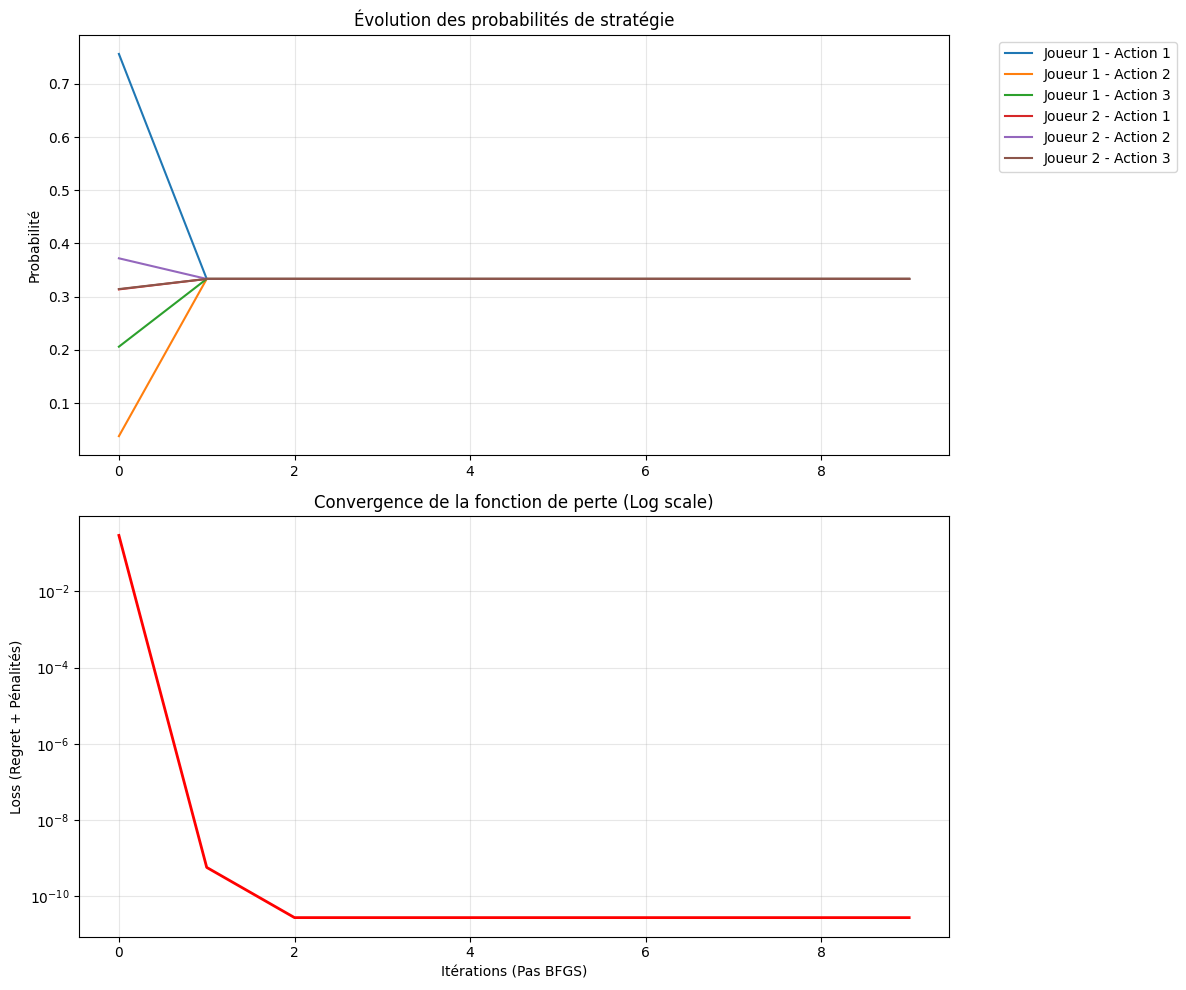


Distributions finales :
Joueur 0: [0.33 0.33 0.33]
Joueur 1: [0.33 0.33 0.33]


In [62]:
# Configuration du jeu : Pierre-Papier-Ciseaux
# Gains pour Joueur 0 (Matrice de gain)
# P1 \ P2 | Pierre | Papier | Ciseaux
# Pierre   |    0   |   -1   |    1
# Papier   |    1   |    0   |   -1
# Ciseaux  |   -1   |    1   |    0

payoffs_p0 = torch.tensor([
    [0., -1., 1.],
    [1., 0., -1.],
    [-1., 1., 0.]
])
payoffs_p1 = -payoffs_p0  # Somme nulle

# Tenseur global (2 joueurs, actions [3, 3])
game_tensor = torch.stack([payoffs_p0, payoffs_p1])

# Initialisation et résolution
game = GameMinimizer(num_players=2, num_actions=[3, 3], payoff_tensor=game_tensor)
final_strategies = game.solve()
game.plot_evolution()


## Gardien et tireur

Itération 0, Loss: 0.021325


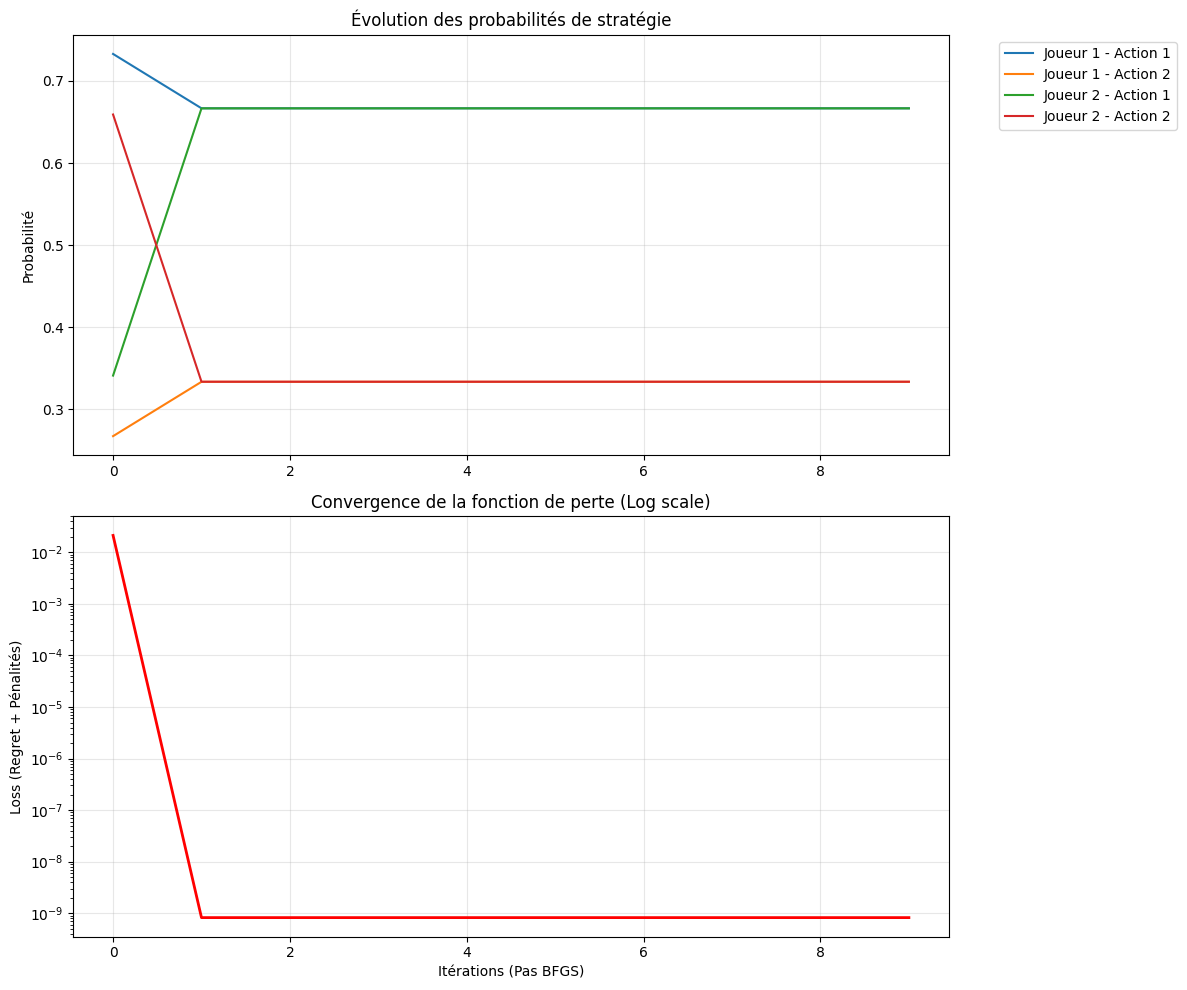


Distributions finales :
Joueur 0: [0.67 0.33]
Joueur 1: [0.67 0.33]


In [51]:
# Matrice de gain pour le Gardien (P0)
# Colonnes = Gardien (G, D) | Lignes = Tireur (G, D)
payoffs_p0 = torch.tensor([
    [ 0.5, 1],  # Tireur tire à Gauche
    [1,  0]   # Tireur tire à Droite
], dtype=torch.float64)

payoffs_p1 = -payoffs_p0  # Somme nulle

# Tenseur global [2 joueurs, 2 actions, 2 actions]
game_tensor_penalty = torch.stack([payoffs_p0, payoffs_p1])

# Création de l'instance pour le Penalty
penalty_game = GameMinimizer(
    num_players=2, 
    num_actions=[2, 2], 
    payoff_tensor=game_tensor_penalty
)

# Lancement de la résolution
# On surveille le gradient pour voir si L-BFGS "travaille" bien
final_strats = penalty_game.solve(iterations=10)

penalty_game.plot_evolution()


## Jeu de coopération

Itération 0, Loss: 0.028800
Itération 10, Loss: 0.000000


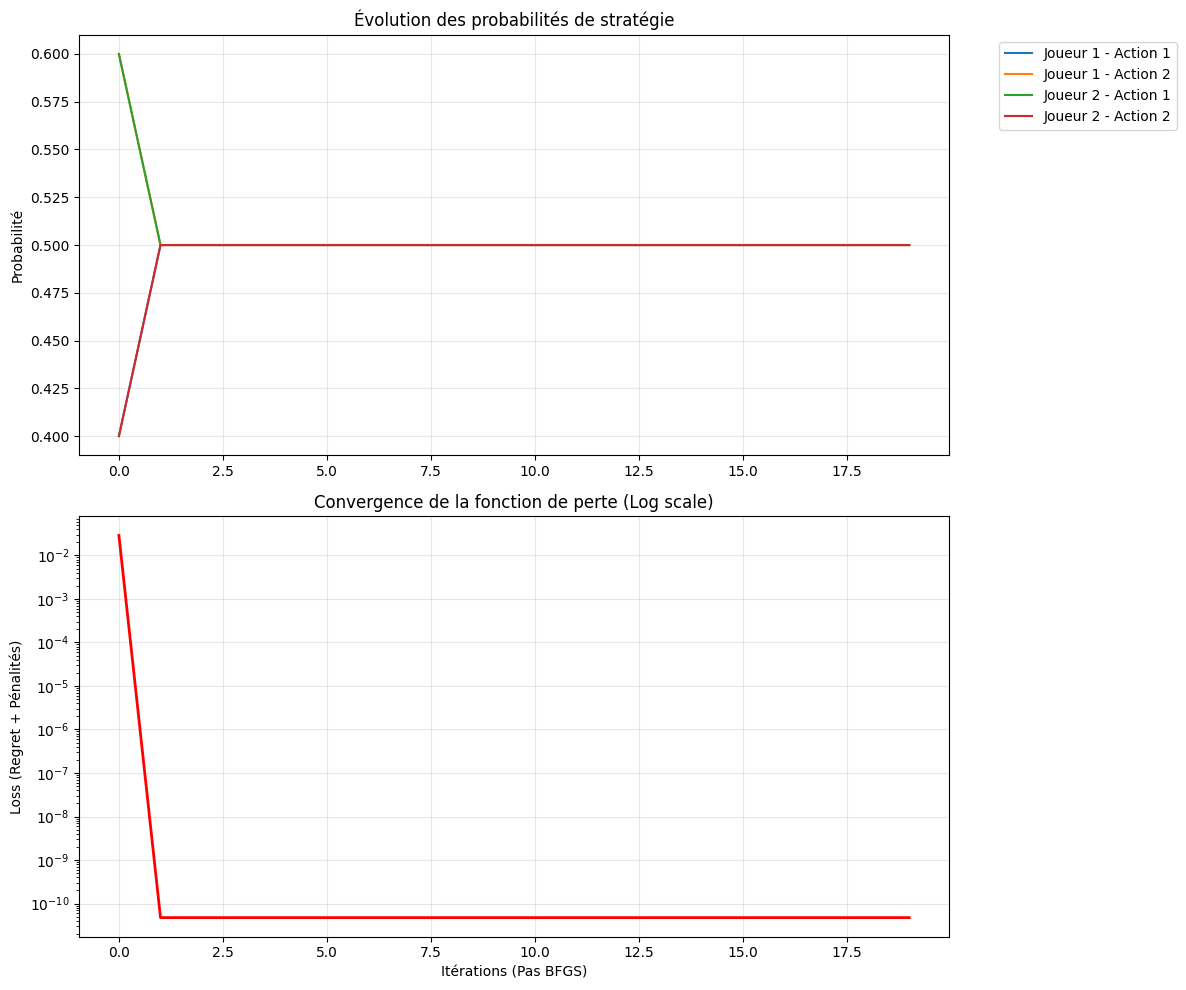


Distributions finales :
Joueur 0: [0.5 0.5]
Joueur 1: [0.5 0.5]


In [52]:
# Matrice de gain pour le Gardien (P0)
# Colonnes = Gardien (G, D) | Lignes = Tireur (G, D)
payoffs_p0 = torch.tensor([
    [ 1.0, 0.0],  # Tireur tire à Gauche
    [0.0,  1.0]   # Tireur tire à Droite
], dtype=torch.float64)

payoffs_p1 = payoffs_p0 

# Tenseur global [2 joueurs, 2 actions, 2 actions]
game_tenseur_cooperation = torch.stack([payoffs_p0, payoffs_p1])

strategies_initales = [[0.4,0.6],[0.6,0.4]]
# Création de l'instance pour le Penalty
game_cooperation = GameMinimizer(
    num_players=2, 
    num_actions=[2, 2], 
    payoff_tensor=game_tenseur_cooperation,
    strategies_init=strategies_initales
)

# Lancement de la résolution
# On surveille le gradient pour voir si L-BFGS "travaille" bien
final_strats = game_cooperation.solve(iterations=20)

game_cooperation.plot_evolution()



Itération 0, Loss: 0.363600
Itération 10, Loss: 0.000000
Itération 20, Loss: 0.000000
Itération 30, Loss: 0.000000
Itération 40, Loss: 0.000000


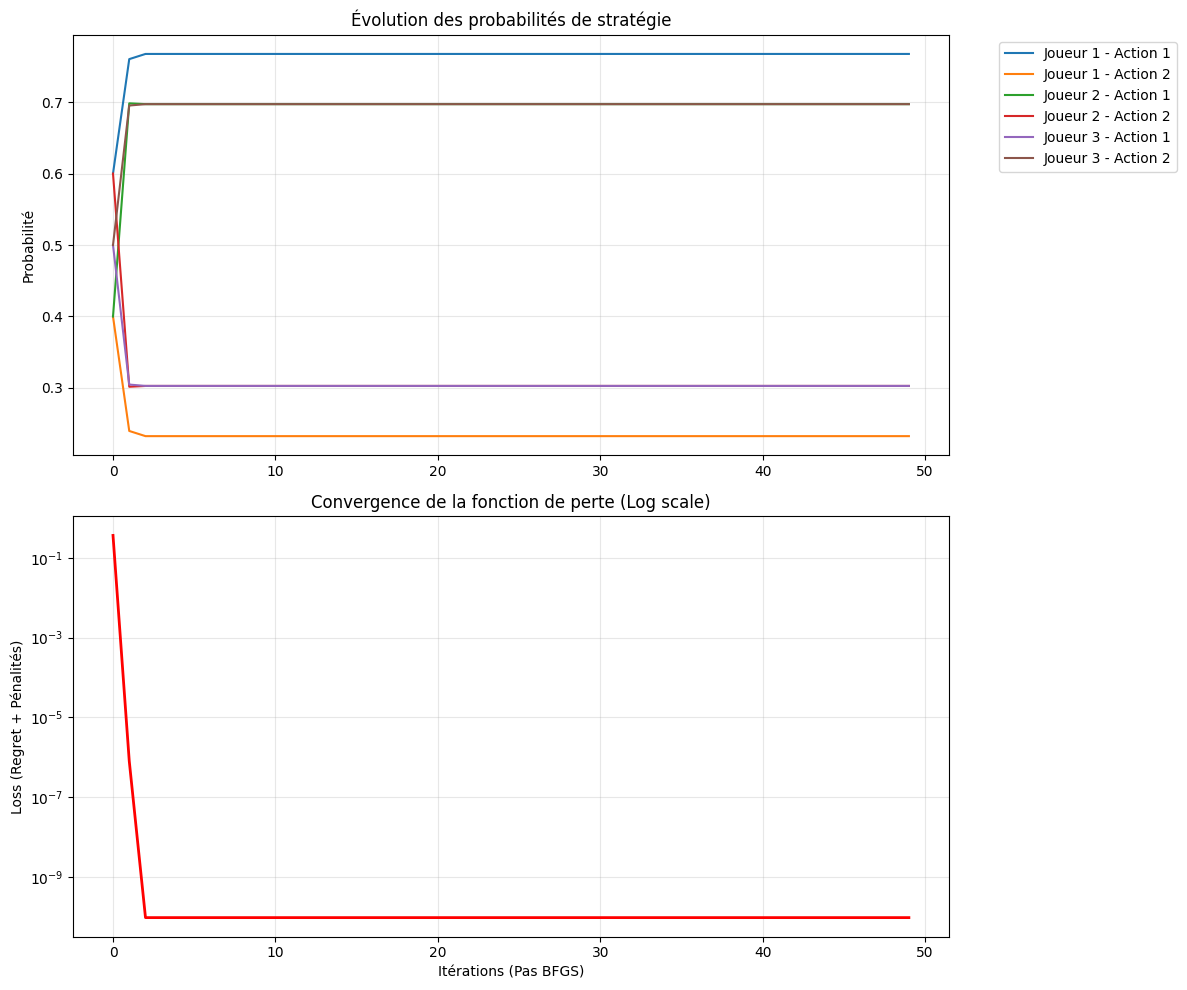


Distributions finales :
Joueur 0: [0.77 0.23]
Joueur 1: [0.7 0.3]
Joueur 2: [0.3 0.7]


In [53]:
# 1. On définit les gains pour chaque joueur sous forme de matrices 2x2
# Pour 3 joueurs, on a besoin de "tranches" (slices) : 
# Gain quand J2 choisit Action 0 (G) vs Gain quand J2 choisit Action 1 (D)

# --- Joueur 0 ---
p0_si_J2_G = torch.tensor([[1.0, 0.0], [0.0, 0.0]], dtype=torch.float64) # J2 joue G
p0_si_J2_D = torch.tensor([[0.0, 0.0], [0.0, 1.0]], dtype=torch.float64) # J2 joue D
payoff_p0 = torch.stack([p0_si_J2_G, p0_si_J2_D], dim=2) # On empile sur la 3ème dimension

# --- Joueur 1 --- (Même logique de coopération)
p1_si_J2_G = torch.tensor([[1.0, -5], [0.0, 0.0]], dtype=torch.float64)
p1_si_J2_D = torch.tensor([[0.0, 2], [-1, 1.0]], dtype=torch.float64)
payoff_p1 = torch.stack([p1_si_J2_G, p1_si_J2_D], dim=2)

# --- Joueur 2 ---
p2_si_J2_G = torch.tensor([[1.0, 1], [0.0, 0.0]], dtype=torch.float64)
p2_si_J2_D = torch.tensor([[0.0, 3], [0.0, 1.0]], dtype=torch.float64)
payoff_p2 = torch.stack([p2_si_J2_G, p2_si_J2_D], dim=2)

# 2. Tenseur global [Nb_joueurs, Act_J0, Act_J1, Act_J2] -> Taille [3, 2, 2, 2]
game_tensor_3p = torch.stack([payoff_p0, payoff_p1, payoff_p2])

# 3. Initialisation (3 joueurs, 2 actions chacun)
# On donne les probas complètes, le __init__ s'occupera de garder n-1
strategies_initiales_3p = [[0.6, 0.4], [0.4, 0.6], [0.5, 0.5]]

game_3p = GameMinimizer(
    num_players=3, 
    num_actions=[2, 2, 2], 
    payoff_tensor=game_tensor_3p,
    strategies_init=strategies_initiales_3p
)

# 4. Résolution
final_strats = game_3p.solve(iterations=50)

# 5. Affichage
game_3p.plot_evolution()
